# Week 3: Statistical Analysis and Hypothesis Testing in Python

## E-Commerce Sales Statistical Analysis

This project investigates relationships and differences within an e-commerce sales dataset using descriptive statistics and formal hypothesis testing.

### Dataset
E-Commerce Sales Analytics Dataset

### Tools
Python, Pandas, NumPy, SciPy, Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    levene,
    shapiro
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load dataset

In [ ]:
file_path = "../Week-2-Advanced-Data-Visualization/ecommerce_sales_analytics_5000.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (5000, 12)


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


# Dataset information

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (5000, 12)

Columns:
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']

Data Types:
order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate Rows:
0


# Data preparation

In [4]:
# Convert date
df["order_date"] = pd.to_datetime(df["order_date"])

# Create useful time features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")

# Create discount group
df["discount_group"] = np.where(
    df["discount"] > 0,
    "Discounted",
    "Non-Discounted"
)

print(df.head())

   order_id order_date  customer_id product_category region  quantity  \
0     10001 2022-01-01         1102           Beauty  South         7   
1     10002 2022-01-02         1435         Clothing  South         7   
2     10003 2022-01-03         1860           Beauty   East         3   
3     10004 2022-01-04         1270      Electronics   West         5   
4     10005 2022-01-05         1106         Clothing   West         5   

   unit_price  discount payment_method  delivery_days  customer_rating  \
0      373.65      0.28         Wallet             10              4.7   
1       47.74      0.09           Card              6              3.9   
2      311.28      0.31            COD              6              2.5   
3      524.47      0.02         Wallet              6              1.6   
4      139.87      0.33         Wallet              4              4.9   

   revenue  year  month month_name discount_group  
0  1883.20  2022      1        Jan     Discounted  
1   304.10  

# Descriptive statistics

In [5]:
print("========== DESCRIPTIVE STATISTICS ==========")

display(df.describe())

print("\nAverage Revenue:")
print(df["revenue"].mean())

print("\nMedian Revenue:")
print(df["revenue"].median())

print("\nStandard Deviation of Revenue:")
print(df["revenue"].std())

========== DESCRIPTIVE STATISTICS ==========


,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue,year,month
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148,2028.352800,6.430600
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000,2022.000000,1.000000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500,2025.000000,3.000000
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000,2028.000000,6.000000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000,2032.000000,9.000000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000,2035.000000,12.000000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219,3.954827,3.427584



Average Revenue:
1021.955148

Median Revenue:
796.65

Standard Deviation of Revenue:
825.5842191911942


# Revenue by category

In [6]:
category_stats = (
    df.groupby("product_category")["revenue"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(category_stats)

,count,mean,median,std
product_category,,,,
Beauty,723,1059.281992,821.64,867.590231
Electronics,1777,1029.768835,796.49,831.796825
Home,969,1013.502497,802.83,812.271060
Clothing,1531,1000.608570,785.22,806.210745


## Research Question

Does average revenue differ significantly among different product categories?

This question is relevant to e-commerce businesses because identifying statistically significant differences in revenue across categories can help management make better decisions about inventory, pricing, marketing, and product strategy.

## Hypothesis Formulation

### Null Hypothesis (H₀)

There is no statistically significant difference in mean revenue among the different product categories.

### Alternative Hypothesis (H₁)

There is a statistically significant difference in mean revenue among at least one pair of product categories.

### Significance Level

α = 0.05

### Decision Rule

If p-value < 0.05:
Reject H₀.

If p-value ≥ 0.05:
Fail to reject H₀.

## Visualization 1 — Revenue distribution by category

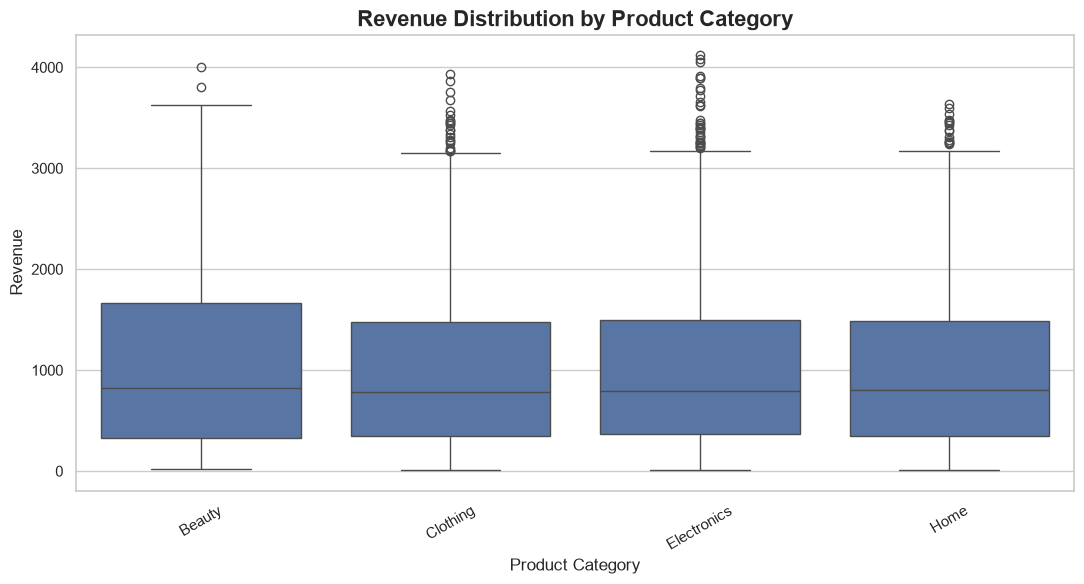

In [10]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="product_category",
    y="revenue"
)

plt.title(
    "Revenue Distribution by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## One-Way ANOVA

In [11]:
# Get revenue groups for each category
groups = [
    group["revenue"].values
    for name, group in df.groupby("product_category")
]

categories = df["product_category"].unique()

print("Categories:")
print(categories)

# Perform ANOVA
anova_result = f_oneway(*groups)

print("\n========== ONE-WAY ANOVA ==========")

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

Categories:
<StringArray>
['Beauty', 'Clothing', 'Electronics', 'Home']
Length: 4, dtype: str

========== ONE-WAY ANOVA ==========
F-statistic: 0.92070443964241
p-value: 0.4298559159051377


## ANOVA interpretation

In [12]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print(
        "\nResult: Reject the Null Hypothesis (H₀)."
    )
    print(
        "There is statistically significant evidence "
        "that average revenue differs among product categories."
    )
else:
    print(
        "\nResult: Fail to Reject the Null Hypothesis (H₀)."
    )
    print(
        "There is not enough statistical evidence "
        "to conclude that average revenue differs among product categories."
    )


Result: Fail to Reject the Null Hypothesis (H₀).
There is not enough statistical evidence to conclude that average revenue differs among product categories.


## ANOVA assumption — equal variance

In [13]:
levene_result = levene(*groups)

print("========== LEVENE'S TEST ==========")

print("Statistic:", levene_result.statistic)
print("p-value:", levene_result.pvalue)

if levene_result.pvalue < 0.05:
    print(
        "\nVariances may be significantly different."
    )
else:
    print(
        "\nNo significant evidence of unequal variances."
    )

========== LEVENE'S TEST ==========
Statistic: 1.7592145694179069
p-value: 0.15270755993850363

No significant evidence of unequal variances.


## Post-hoc analysis

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------
     Beauty    Clothing -58.6734 0.3931 -154.4165  37.0697  False
     Beauty Electronics -29.5132 0.8496 -123.1064  64.0801  False
     Beauty        Home -45.7795  0.672 -150.0488  58.4898  False
   Clothing Electronics  29.1603 0.7419  -44.8239 103.1444  False
   Clothing        Home  12.8939 0.9813   -74.204  99.9919  False
Electronics        Home -16.2663 0.9606 -100.9953  68.4626  False
-----------------------------------------------------------------


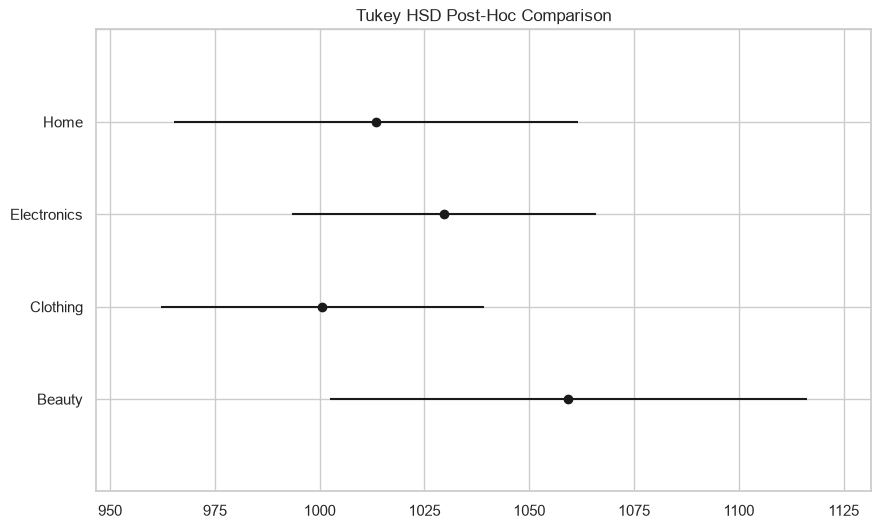

In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df["revenue"],
    groups=df["product_category"],
    alpha=0.05
)

print(tukey_result)

tukey_result.plot_simultaneous(
    figsize=(10, 6)
)

plt.title(
    "Tukey HSD Post-Hoc Comparison"
)

plt.show()

## Hypothesis Test 2: Discount and Revenue

### Research Question

Do discounted and non-discounted orders have significantly different average revenue?

### Null Hypothesis (H₀)

There is no statistically significant difference in mean revenue between discounted and non-discounted orders.

### Alternative Hypothesis (H₁)

There is a statistically significant difference in mean revenue between discounted and non-discounted orders.

### Significance Level

α = 0.05

# Visualization 2 — Discount groups

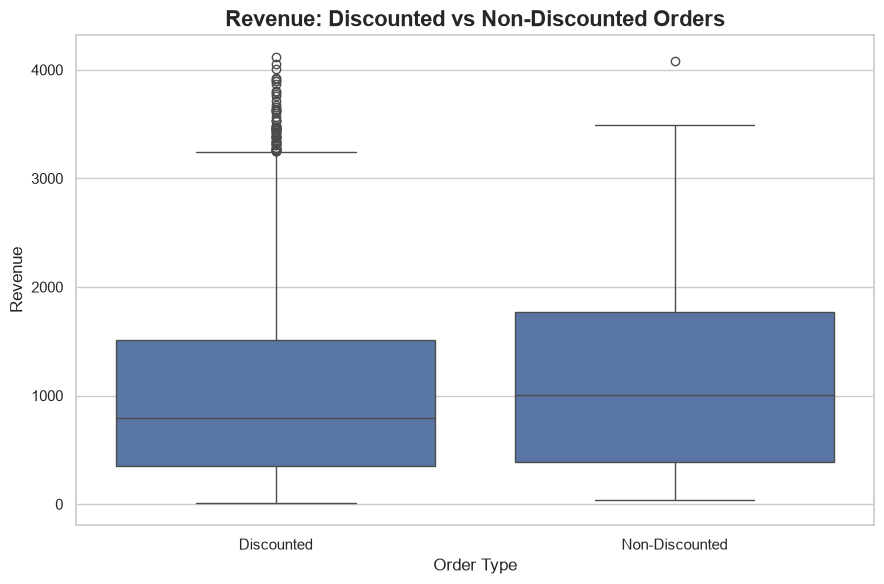

In [17]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="discount_group",
    y="revenue"
)

plt.title(
    "Revenue: Discounted vs Non-Discounted Orders",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Order Type")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# Independent t-test

In [18]:
discounted = df[
    df["discount"] > 0
]["revenue"]

non_discounted = df[
    df["discount"] == 0
]["revenue"]

print("Discounted Orders:", len(discounted))
print("Non-Discounted Orders:", len(non_discounted))

t_result = ttest_ind(
    discounted,
    non_discounted,
    equal_var=False
)

print("\n========== WELCH'S T-TEST ==========")

print("T-statistic:", t_result.statistic)
print("p-value:", t_result.pvalue)

Discounted Orders: 4932
Non-Discounted Orders: 68

========== WELCH'S T-TEST ==========
T-statistic: -1.5342203550200713
p-value: 0.12959291485742738


# T-test interpretation

In [19]:
if t_result.pvalue < 0.05:

    print(
        "\nResult: Reject H₀."
    )

    print(
        "There is statistically significant evidence "
        "of a difference in average revenue between "
        "discounted and non-discounted orders."
    )

else:

    print(
        "\nResult: Fail to Reject H₀."
    )

    print(
        "There is not enough evidence to conclude "
        "that discounted and non-discounted orders "
        "have different average revenue."
    )


Result: Fail to Reject H₀.
There is not enough evidence to conclude that discounted and non-discounted orders have different average revenue.


# Confidence interval for difference

In [20]:
mean_discounted = discounted.mean()
mean_non_discounted = non_discounted.mean()

difference = mean_discounted - mean_non_discounted

print("Mean Revenue - Discounted:", mean_discounted)
print("Mean Revenue - Non-Discounted:", mean_non_discounted)

print(
    "\nDifference in Mean Revenue:",
    difference
)

Mean Revenue - Discounted: 1019.4827412814274
Mean Revenue - Non-Discounted: 1201.2773529411766

Difference in Mean Revenue: -181.7946116597492


For a 95% CI:

In [21]:
# Welch confidence interval

n1 = len(discounted)
n2 = len(non_discounted)

var1 = discounted.var()
var2 = non_discounted.var()

se = np.sqrt(
    (var1 / n1) +
    (var2 / n2)
)

df_welch = (
    ((var1 / n1) + (var2 / n2)) ** 2
    /
    (
        ((var1 / n1) ** 2 / (n1 - 1))
        +
        ((var2 / n2) ** 2 / (n2 - 1))
    )
)

t_critical = stats.t.ppf(
    0.975,
    df_welch
)

margin = t_critical * se

lower = difference - margin
upper = difference + margin

print("\n95% Confidence Interval:")
print("Lower:", lower)
print("Upper:", upper)


95% Confidence Interval:
Lower: -418.22329815200163
Upper: 54.634074832503245


## Hypothesis Test 3: Region and Payment Method

### Research Question

Is there a statistically significant association between customer region and payment method?

### Null Hypothesis (H₀)

Region and payment method are independent.

### Alternative Hypothesis (H₁)

Region and payment method are associated.

### Significance Level

α = 0.05

# Contingency table

In [22]:
contingency_table = pd.crosstab(
    df["region"],
    df["payment_method"]
)

print("========== CONTINGENCY TABLE ==========")

display(contingency_table)

========== CONTINGENCY TABLE ==========


payment_method,COD,Card,Wallet
region,,,
East,461,548,218
North,429,601,246
South,438,526,244
West,446,595,248


# Visualization 3 — Payment method by region

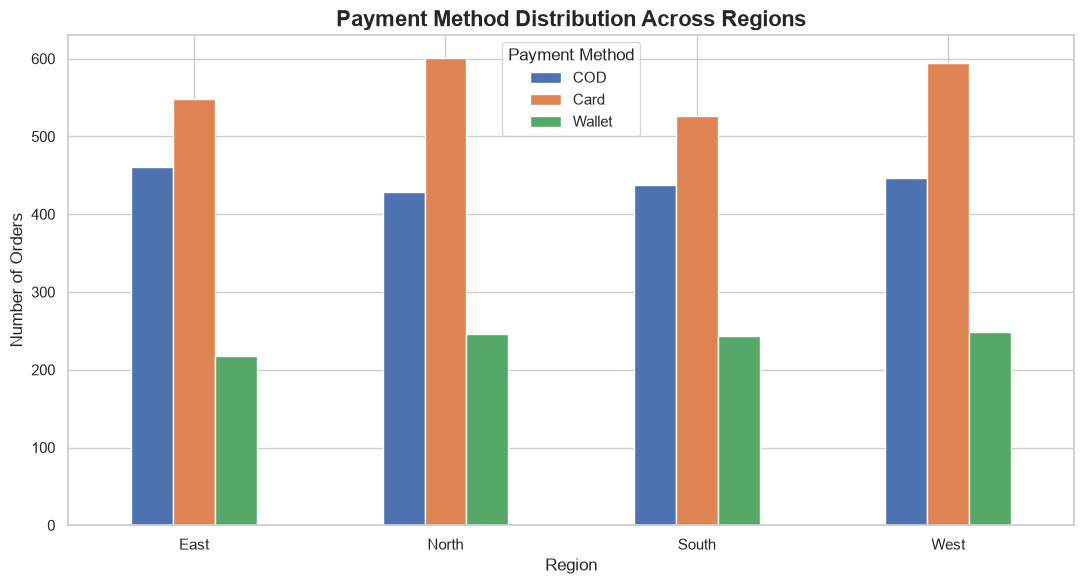

In [23]:
contingency_table.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Payment Method Distribution Across Regions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.legend(
    title="Payment Method"
)

plt.tight_layout()
plt.show()

# Chi-square test

In [24]:
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("========== CHI-SQUARE TEST ==========")

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

========== CHI-SQUARE TEST ==========
Chi-square statistic: 7.220921846845685
p-value: 0.3008989616592611
Degrees of freedom: 6


# Chi-square interpretation

In [25]:
if p_value < 0.05:

    print(
        "\nResult: Reject H₀."
    )

    print(
        "There is statistically significant evidence "
        "of an association between region and payment method."
    )

else:

    print(
        "\nResult: Fail to Reject H₀."
    )

    print(
        "There is not enough statistical evidence "
        "to conclude that region and payment method are associated."
    )


Result: Fail to Reject H₀.
There is not enough statistical evidence to conclude that region and payment method are associated.


# Visualization 4 — Revenue distribution

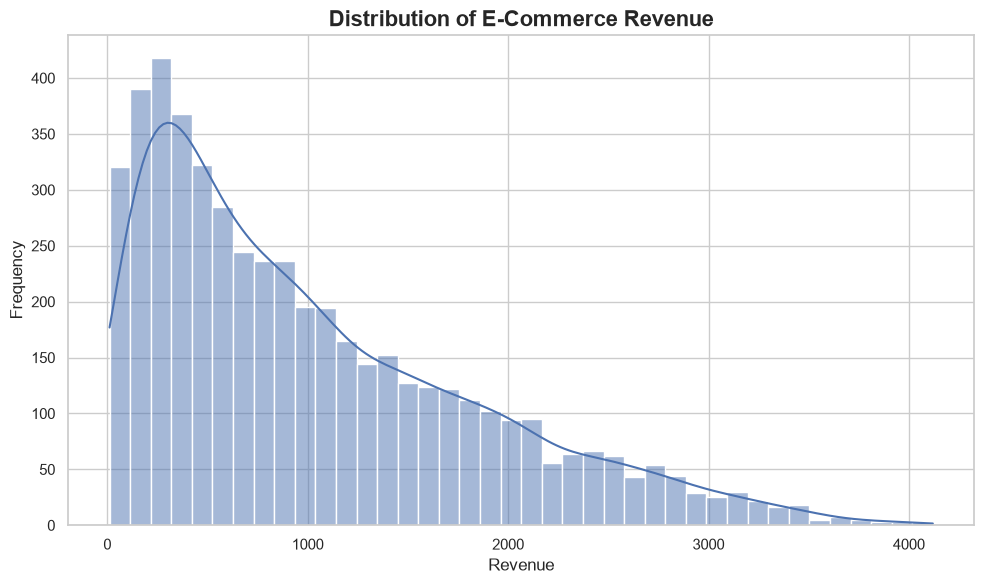

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="revenue",
    bins=40,
    kde=True
)

plt.title(
    "Distribution of E-Commerce Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Summary of all statistical tests

In [27]:
summary = pd.DataFrame({
    "Test": [
        "One-Way ANOVA",
        "Welch's T-Test",
        "Chi-Square Test"
    ],
    "Statistic": [
        anova_result.statistic,
        t_result.statistic,
        chi2
    ],
    "P-Value": [
        anova_result.pvalue,
        t_result.pvalue,
        p_value
    ]
})

summary["Significance Level"] = 0.05

summary["Decision"] = np.where(
    summary["P-Value"] < 0.05,
    "Reject H0",
    "Fail to Reject H0"
)

display(summary)

,Test,Statistic,P-Value,Significance Level,Decision
0,One-Way ANOVA,0.920704,0.429856,0.05,Fail to Reject H0
1,Welch's T-Test,-1.534220,0.129593,0.05,Fail to Reject H0
2,Chi-Square Test,7.220922,0.300899,0.05,Fail to Reject H0


# Final statistical conclusion

In [28]:
print("=" * 60)
print("FINAL STATISTICAL SUMMARY")
print("=" * 60)

print("\n1. ANOVA")
print(f"F-statistic = {anova_result.statistic:.4f}")
print(f"p-value = {anova_result.pvalue:.6f}")

print("\n2. Welch's T-Test")
print(f"T-statistic = {t_result.statistic:.4f}")
print(f"p-value = {t_result.pvalue:.6f}")

print("\n3. Chi-Square")
print(f"Chi-square = {chi2:.4f}")
print(f"p-value = {p_value:.6f}")

FINAL STATISTICAL SUMMARY

1. ANOVA
F-statistic = 0.9207
p-value = 0.429856

2. Welch's T-Test
T-statistic = -1.5342
p-value = 0.129593

3. Chi-Square
Chi-square = 7.2209
p-value = 0.300899
